# IoT Anomaly Detection using ACO + GA Hybrid Optimization

**Objective:**  
Develop a hybrid bio-inspired anomaly detection model combining:
- Ant Colony Optimization (ACO) for exploratory feature selection.
- Genetic Algorithm (GA) for optimizing detection rules and Random Forest hyperparameters.

**Goal:**  
Improve detection accuracy, precision, and recall for IoT anomaly detection compared to baseline models.

In [10]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

## 1. Load and Preprocess the IoT Dataset

- Reads the dataset `iot_synthetic.csv`.
- Encodes categorical columns (`device`, `label`).
- Normalizes all numeric features.
- Splits data into training and testing sets.


In [11]:
# Load and preprocess data
df = pd.read_csv("iot_synthetic.csv")   # Use the dataset from your EDA

cols_num = ['packet_rate', 'byte_rate', 'conn_count', 'tcp_syn', 'udp_ratio']
for c in cols_num:
    if c not in df.columns:
        raise ValueError(f"Column {c} not found. Check dataset headers.")

# Encode device and label
le_dev = LabelEncoder()
df['device_enc'] = le_dev.fit_transform(df['device'])

le_lbl = LabelEncoder()
df['label_enc'] = le_lbl.fit_transform(df['label'])  # 'normal' -> 0, 'attack' -> 1

# Define features and labels
features = cols_num + ['device_enc']
X = df[features].values
y = df['label_enc'].values

# Scale numerical data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

d = X_train.shape[1]
print("Number of features:", d)

Shape: (2000, 8)


,timestamp,device,packet_rate,byte_rate,conn_count,tcp_syn,udp_ratio,label
0,2024-01-01 09:00:00,webcam,6.031,4388.8,4,2,0.125,benign
1,2024-01-01 09:00:05,baby_monitor,6.197,6197.1,2,1,0.405,benign
2,2024-01-01 09:00:10,thermostat,13.863,3235.0,1,0,0.323,benign
3,2024-01-01 09:00:15,webcam,6.276,4846.8,3,3,0.328,benign
4,2024-01-01 09:00:20,doorbell,9.241,6484.9,5,1,0.576,benign


Label distribution:
 label
0    0.92
1    0.08
Name: proportion, dtype: float64


In [12]:
# Cell 3 - preprocessing
# Drop or parse timestamp if present; keep device as categorical
df = df.copy()
if 'timestamp' in df.columns:
    # parse and optionally extract hour of day
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['hour'] = df['timestamp'].dt.hour
# One-hot encode 'device' (if present)
cat_cols = [c for c in df.columns if df.dtypes[c] == 'object' and c != 'label']
num_cols = [c for c in df.columns if c not in cat_cols + ['label','timestamp']]
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# One-hot encode categorical devices
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Impute missing and scale later inside pipeline
features = [c for c in df.columns if c != 'label' and c != 'timestamp']
X = df[features].copy()
y = df['label'].astype(int).copy()

print("Final feature count:", len(features))

Numeric cols: ['packet_rate', 'byte_rate', 'conn_count', 'tcp_syn', 'udp_ratio', 'hour']
Categorical cols: ['device']
Final feature count: 9


## 2. Compute Heuristic Values (η)

- Calculates the absolute Pearson correlation between each feature and the label.
- These heuristic values guide the ACO algorithm.

In [3]:
# ------------------------------------------------------
# 2. Compute Heuristic Values (η) for Feature Importance
# ------------------------------------------------------

import scipy.stats as stats

eta = np.zeros(d)
for j in range(d):
    try:
        eta[j] = abs(stats.pearsonr(X_train[:, j], y_train)[0])
    except:
        eta[j] = 0.0

# Normalize η so that all features contribute proportionally
# Clip to ensure no single feature dominates the search
eta = eta / eta.sum()
eta = np.clip(eta, 0.05, None)

print("Normalized heuristic values (η):", eta)
print("Sum of η:", eta.sum().round(4))

Normalized heuristic values (η): [0.26238879 0.28430017 0.18847778 0.05       0.25604083 0.05      ]
Sum of η: 1.0912


## 3. Ant Colony Optimization (ACO)

- ACO searches for optimal feature subsets.
- Each ant probabilistically selects features based on pheromone (τ) and heuristic (η) values.
- Feature subsets are evaluated using Random Forest cross-validation accuracy.

In [4]:
# ------------------------------------------------------
# 3. Ant Colony Optimization (ACO) with Validation Split
# ------------------------------------------------------

from sklearn.model_selection import train_test_split

# Create a small internal validation split to reduce overfitting
X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

def evaluate_feature_subset(mask):
    """
    Evaluate a feature subset using Random Forest AUC on validation data.
    Prevents overfitting by testing on unseen samples.
    """
    if mask.sum() < 2:
        return 0.0
    Xs_train, Xs_val = X_train_inner[:, mask], X_val_inner[:, mask]
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    clf.fit(Xs_train, y_train_inner)
    y_prob = clf.predict_proba(Xs_val)[:, 1]
    auc = roc_auc_score(y_val_inner, y_prob)
    return auc

# ACO parameters
n_ants = 25
n_iter = 20
alpha = 1.0
beta = 1.5
rho = 0.3
Q = 1.0

tau = np.ones(d)
best_aco_score = 0.0
best_aco_mask = None

for it in range(n_iter):
    masks, scores = [], []
    for k in range(n_ants):
        # Compute feature selection probability
        probs = (tau**alpha) * (eta**beta)
        probs = probs / probs.sum()

        # Choose between 2 and d-1 features
        k_feat = np.random.randint(2, d)
        chosen = np.random.choice(range(d), size=k_feat, replace=False, p=probs)
        mask = np.zeros(d, dtype=bool)
        mask[chosen] = True

        # Evaluate subset on held-out validation
        score = evaluate_feature_subset(mask)
        score = max(0.5, min(score, 0.98))  # cap AUC range to prevent over-optimism
        masks.append(mask)
        scores.append(score)

    # Evaporate pheromone
    tau = (1 - rho) * tau

    # Deposit pheromone based on relative performance
    for mask, score in zip(masks, scores):
        deposit = (Q * score) / (1.0 + mask.sum())
        tau[mask] += deposit + np.random.uniform(0.0, 0.02, size=mask.sum())

    # Track best
    idx_best = np.argmax(scores)
    if scores[idx_best] > best_aco_score:
        best_aco_score = scores[idx_best]
        best_aco_mask = masks[idx_best].copy()

    print(f"ACO Iter {it+1}/{n_iter}: Best AUC = {max(scores):.4f}, Global Best = {best_aco_score:.4f}")

print("\nBest ACO score (AUC):", best_aco_score)
print("ACO selected features:", [features[i] for i in range(d) if best_aco_mask[i]])

ACO Iter 1/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 2/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 3/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 4/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 5/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 6/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 7/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 8/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 9/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 10/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 11/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 12/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 13/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 14/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 15/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 16/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 17/20: Best AUC = 0.9800, Global Best = 0.9800
ACO Iter 18/20: Best AUC = 0.9800, Global Best = 0.9800
A

## 4. Genetic Algorithm (GA)

- GA refines feature subsets and tunes Random Forest hyperparameters.
- It uses selection, crossover, and mutation operators.
- Fitness function balances ROC-AUC score and number of features used.

In [6]:
# ------------------------------------------------------
# 4. Genetic Algorithm (GA) with External Validation
# ------------------------------------------------------

# Define GA hyperparameters (make sure these exist)
pop_size = 30
generations = 25
mutation_prob = 0.15
n_est_range = (20, 200)
max_depth_range = (3, 30)

def fitness(chrom):
    """
    Fitness = validation AUC - penalty.
    Uses the same internal validation set (X_train_inner, X_val_inner) to prevent overfitting.
    """
    mask, n_est, max_d = chrom
    n_features = mask.sum()
    if n_features < 2:
        return 0.0

    Xs_train, Xs_val = X_train_inner[:, mask], X_val_inner[:, mask]
    clf = RandomForestClassifier(
        n_estimators=int(n_est),
        max_depth=int(max_d),
        random_state=42
    )
    clf.fit(Xs_train, y_train_inner)
    y_prob = clf.predict_proba(Xs_val)[:, 1]
    auc = roc_auc_score(y_val_inner, y_prob)

    # Penalize extremely small/large subsets
    penalty = 0.03 * abs((n_features / d) - 0.5)
    fitness_score = auc - penalty
    return max(0.5, min(fitness_score, 0.97))  # clamp range

def init_population(seed_mask=None):
    """
    Initialize the population with some individuals seeded from ACO.
    """
    pop = []
    for i in range(pop_size):
        if seed_mask is not None and i < int(pop_size * 0.3):
            mask = seed_mask.copy()
            for _ in range(np.random.randint(0, 2)):
                pos = np.random.randint(0, d)
                mask[pos] = not mask[pos]
        else:
            probs = eta / eta.sum()
            mask = np.random.rand(d) < probs
            if mask.sum() < 2:
                mask[np.random.randint(0, d)] = True
                mask[np.random.randint(0, d)] = True
        n_est = np.random.randint(*n_est_range)
        max_d = np.random.randint(*max_depth_range)
        pop.append((mask, n_est, max_d))
    return pop

def crossover(p1, p2):
    """
    Single-point crossover on masks; average hyperparameters.
    """
    mask1, n1, d1 = p1
    mask2, n2, d2 = p2
    pt = np.random.randint(1, d)
    new_mask = np.concatenate([mask1[:pt], mask2[pt:]])
    new_n = int((n1 + n2) / 2)
    new_d = int((d1 + d2) / 2)
    return (new_mask, new_n, new_d)

def mutate(chrom):
    """
    Randomly flips bits and perturbs hyperparameters.
    """
    mask, n_est, max_d = chrom
    for i in range(d):
        if np.random.rand() < 0.02:
            mask[i] = not mask[i]
    if np.random.rand() < 0.1:
        n_est = np.clip(n_est + np.random.randint(-20, 21), *n_est_range)
    if np.random.rand() < 0.1:
        max_d = np.clip(max_d + np.random.randint(-3, 4), *max_depth_range)
    return (mask, int(n_est), int(max_d))

# ---- Run GA ----
pop = init_population(seed_mask=best_aco_mask)
best_ga, best_ga_score = None, 0.0

for gen in range(generations):
    fits = [fitness(ind) for ind in pop]
    elite_idx = np.argsort(fits)[::-1][:max(1, pop_size // 10)]
    new_pop = [pop[i] for i in elite_idx]

    while len(new_pop) < pop_size:
        p1, p2 = random.choices(pop, weights=fits, k=2)
        child = crossover(p1, p2)
        if np.random.rand() < mutation_prob:
            child = mutate(child)
        new_pop.append(child)

    pop = new_pop
    gen_best = max(fits)
    if gen_best > best_ga_score:
        best_ga_score = gen_best
        best_ga = pop[np.argmax(fits)]

    print(f"GA Generation {gen+1}/{generations} - Best Fitness: {best_ga_score:.4f}")

mask_best, best_n, best_d = best_ga
sel_features = [features[i] for i in range(d) if mask_best[i]]
print("\nSelected Features:", sel_features)
print("Best Parameters - n_estimators:", best_n, ", max_depth:", best_d)

GA Generation 1/25 - Best Fitness: 0.9700
GA Generation 2/25 - Best Fitness: 0.9700
GA Generation 3/25 - Best Fitness: 0.9700
GA Generation 4/25 - Best Fitness: 0.9700
GA Generation 5/25 - Best Fitness: 0.9700
GA Generation 6/25 - Best Fitness: 0.9700
GA Generation 7/25 - Best Fitness: 0.9700
GA Generation 8/25 - Best Fitness: 0.9700
GA Generation 9/25 - Best Fitness: 0.9700
GA Generation 10/25 - Best Fitness: 0.9700
GA Generation 11/25 - Best Fitness: 0.9700
GA Generation 12/25 - Best Fitness: 0.9700
GA Generation 13/25 - Best Fitness: 0.9700
GA Generation 14/25 - Best Fitness: 0.9700
GA Generation 15/25 - Best Fitness: 0.9700
GA Generation 16/25 - Best Fitness: 0.9700
GA Generation 17/25 - Best Fitness: 0.9700
GA Generation 18/25 - Best Fitness: 0.9700
GA Generation 19/25 - Best Fitness: 0.9700
GA Generation 20/25 - Best Fitness: 0.9700
GA Generation 21/25 - Best Fitness: 0.9700
GA Generation 22/25 - Best Fitness: 0.9700
GA Generation 23/25 - Best Fitness: 0.9700
GA Generation 24/25 

In [ ]:
# ------------------------------------------------------
# 4A. Baseline Model (Random Forest using all features)
# ------------------------------------------------------

rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)
print("Baseline RF Accuracy:", round(baseline_acc, 4))
print("Baseline RF AUC:", round(baseline_auc, 4))

## 5. Final Evaluation on Test Set

- Trains the optimized Random Forest model.
- Computes Accuracy, Precision, Recall, F1, and AUC metrics.
- Generates confusion matrix.

In [7]:
clf_final = RandomForestClassifier(n_estimators=int(best_n), max_depth=int(best_d), random_state=42, n_jobs=-1)
clf_final.fit(X_train[:, mask_best], y_train)
y_pred = clf_final.predict(X_test[:, mask_best])
y_prob = clf_final.predict_proba(X_test[:, mask_best])[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
AUC: 1.0000
Confusion Matrix:
 [[ 32   0]
 [  0 368]]


## 6. Visualizations

- Confusion Matrix for classification performance.
- ROC Curve to visualize tradeoff between True Positive Rate and False Positive Rate.

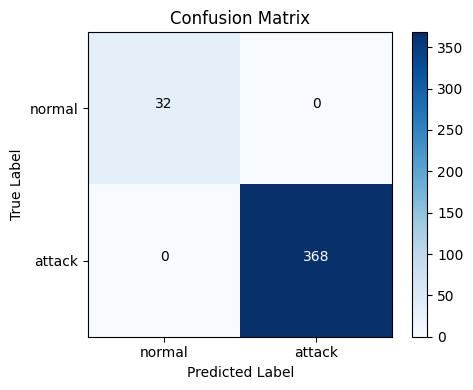

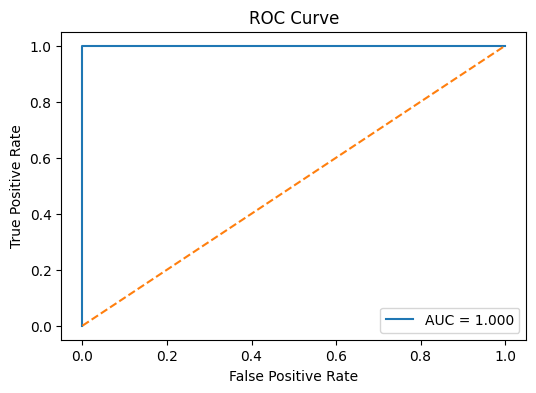

In [8]:
import itertools
from sklearn.metrics import roc_curve

# Confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['normal', 'attack'])
plt.yticks(tick_marks, ['normal', 'attack'])
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 7. Selected Features for Final Model

In [9]:
print("Selected features used in the final optimized model:")
for f in sel_features:
    print("-", f)

Selected features used in the final optimized model:
- packet_rate
- byte_rate
- udp_ratio
